In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.lower().endswith(".csv"):
            print(os.path.join(root, file))

/kaggle/input/datasets/mlg-ulb/creditcardfraud/creditcard.csv
/kaggle/input/datasets/mlg-ulb/creditcardfraud/creditcard.csv


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the credit card fraud dataset
df = pd.read_csv(
    "/kaggle/input/datasets/mlg-ulb/creditcardfraud/creditcard.csv"
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Dataset Inspection and Class Imbalance

The Credit Card Fraud Detection dataset contains transaction records with anonymized numerical features.

The `Class` column is the target variable:

- 0 = Non-Fraudulent transaction
- 1 = Fraudulent transaction

The dataset is highly imbalanced, with fraudulent transactions representing only a very small proportion of all transactions.

In [27]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nClass Distribution:")
print(df["Class"].value_counts())

print("\nClass Distribution (%):")
print(df["Class"].value_counts(normalize=True) * 100)

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V

In [28]:
print("Numerical Summary:")
display(df.describe())

Numerical Summary:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 2. Class Imbalance Analysis

The dataset is extremely imbalanced. Approximately 99.83% of transactions are non-fraudulent, while only 0.17% are fraudulent.

This imbalance makes fraud detection challenging because a model could achieve very high accuracy by predicting almost every transaction as non-fraudulent while failing to identify actual fraud cases.

Therefore, accuracy alone is not an appropriate metric for evaluating fraud detection performance. Precision, Recall, F1-score, and AUC-ROC will also be used.

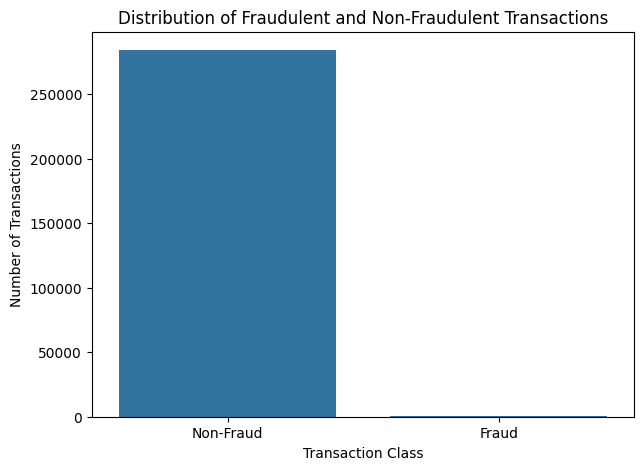

In [29]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Distribution of Fraudulent and Non-Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Non-Fraud", "Fraud"])

plt.show()

## 3. Transaction Amount Analysis

The `Amount` variable represents the transaction amount.

The distribution of transaction amounts is compared between fraudulent and non-fraudulent transactions to identify differences in spending patterns.

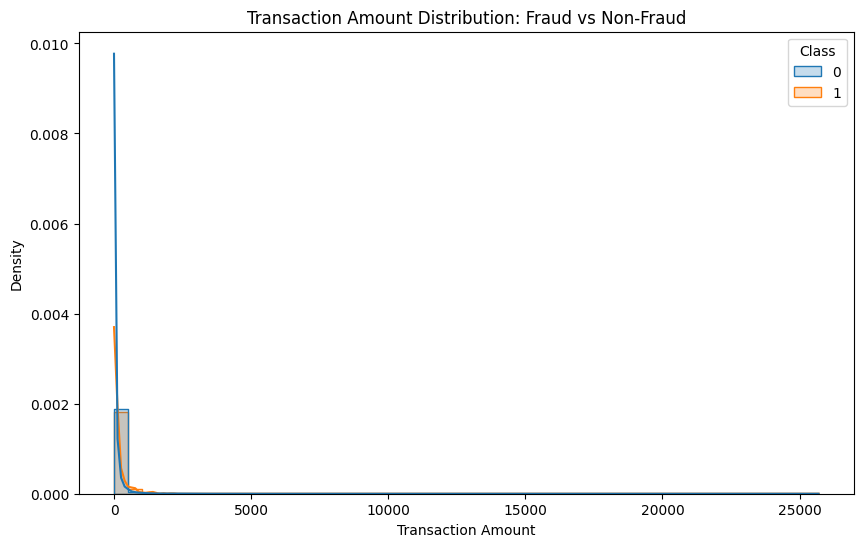

In [30]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")

plt.show()

In [31]:
# Convert elapsed seconds into hour of day
df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)

print("Hour column created successfully.")

display(df[["Time", "Hour", "Amount", "Class"]].head())

Hour column created successfully.


,Time,Hour,Amount,Class
0,0.0,0,149.62,0
1,0.0,0,2.69,0
2,1.0,0,378.66,0
3,1.0,0,123.50,0
4,2.0,0,69.99,0


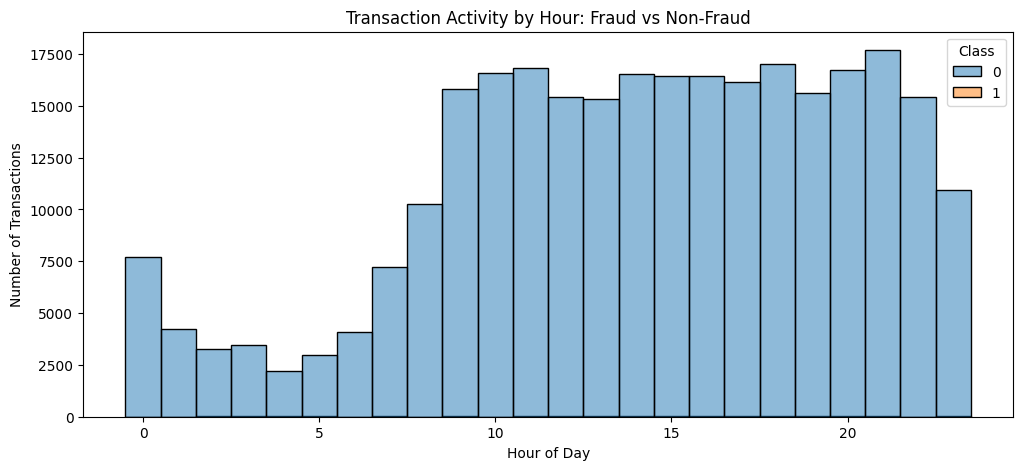

In [32]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="Hour",
    hue="Class",
    bins=24,
    discrete=True,
    stat="count",
    common_norm=False
)

plt.title("Transaction Activity by Hour: Fraud vs Non-Fraud")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

## 4. Feature and Target Preparation

The `Class` column is used as the target variable, where 0 represents non-fraudulent transactions and 1 represents fraudulent transactions.

The `Time` column is retained as a numerical feature, while the temporary `Hour` column created for visualization is removed.

The dataset is then divided into training and testing sets using stratified sampling so that both sets preserve the original fraud/non-fraud class ratio.

In [33]:
from sklearn.model_selection import train_test_split

# Remove the temporary Hour column
df_model = df.drop(columns=["Hour"])

# Separate features and target
X = df_model.drop(columns=["Class"])
y = df_model["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Feature shape: (284807, 30)
Target shape: (284807,)

Training set shape: (227845, 30)
Testing set shape: (56962, 30)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


## 5. Handling Class Imbalance with SMOTE

The dataset contains far fewer fraudulent transactions than legitimate transactions.

SMOTE (Synthetic Minority Over-sampling Technique) is used to create synthetic examples of the minority fraud class.

SMOTE is applied only to the training data. The test data remains unchanged so that model performance is evaluated on the original class distribution.

In [34]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nTraining features after SMOTE:", X_train_smote.shape)
print("Training target after SMOTE:", y_train_smote.shape)

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

Training features after SMOTE: (454902, 30)
Training target after SMOTE: (454902,)


## 6. Class Distribution Before and After SMOTE

The class distribution is visualized before and after SMOTE to demonstrate how oversampling balances the training dataset.

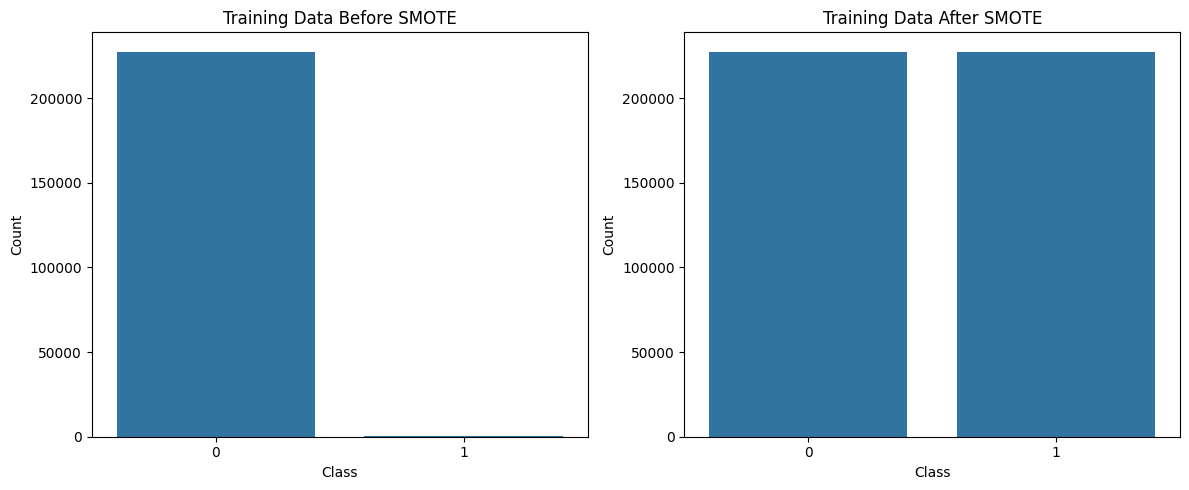

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
sns.countplot(
    x=y_train,
    ax=axes[0]
)
axes[0].set_title("Training Data Before SMOTE")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

# After SMOTE
sns.countplot(
    x=y_train_smote,
    ax=axes[1]
)
axes[1].set_title("Training Data After SMOTE")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 7. Logistic Regression

Logistic Regression is used as a baseline classification model for fraud detection.

Because the dataset is highly imbalanced, the model is trained using the SMOTE-balanced training data. The original test data is retained for unbiased evaluation.

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale the features
scaler = StandardScaler()

X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_smote_scaled,
    y_train_smote
)

# Predictions
logistic_pred = logistic_model.predict(X_test_scaled)
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression training completed.")

Logistic Regression training completed.


## 8. Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

It can capture nonlinear relationships between transaction features and fraud probability. The model is trained using the SMOTE-balanced training data.

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest training completed.")

Random Forest training completed.


## 9. Model Evaluation

Fraud detection requires more than accuracy because fraudulent transactions represent only a small fraction of the dataset.

The models are evaluated using:

- Precision
- Recall
- F1-score
- AUC-ROC

Recall is particularly important because it measures how many actual fraudulent transactions are successfully detected.

In [38]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score
)

evaluation = []

for name, predictions, probabilities in [
    ("Logistic Regression", logistic_pred, logistic_prob),
    ("Random Forest", rf_pred, rf_prob)
]:
    
    evaluation.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, predictions, zero_division=0
        ),
        "AUC-ROC": roc_auc_score(
            y_test, probabilities
        )
    })

fraud_results = pd.DataFrame(evaluation)

display(fraud_results)

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.989853,0.134146,0.897959,0.233422,0.976482
1,Random Forest,0.999403,0.826531,0.826531,0.826531,0.964423


In [39]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report")
print("=" * 55)
print(classification_report(
    y_test,
    logistic_pred,
    target_names=["Non-Fraud", "Fraud"],
    zero_division=0
))

print("\nRandom Forest Classification Report")
print("=" * 55)
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Non-Fraud", "Fraud"],
    zero_division=0
))

Logistic Regression Classification Report
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.99      0.99     56864
       Fraud       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962


Random Forest Classification Report
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



## 10. Confusion Matrix

Confusion matrices are used to examine how well each model distinguishes fraudulent transactions from legitimate transactions.

In fraud detection, False Negatives are particularly important because they represent fraudulent transactions that the model failed to detect.

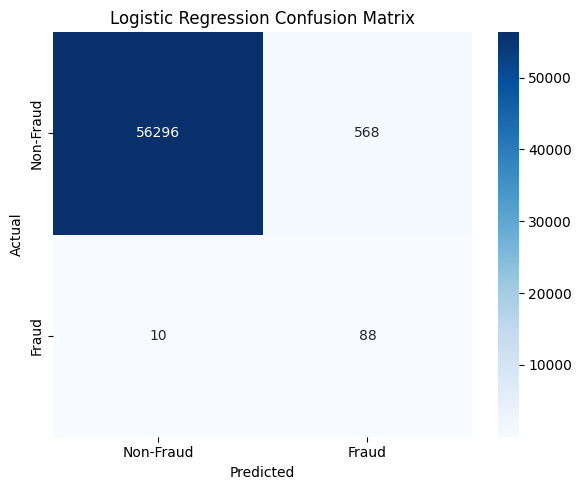

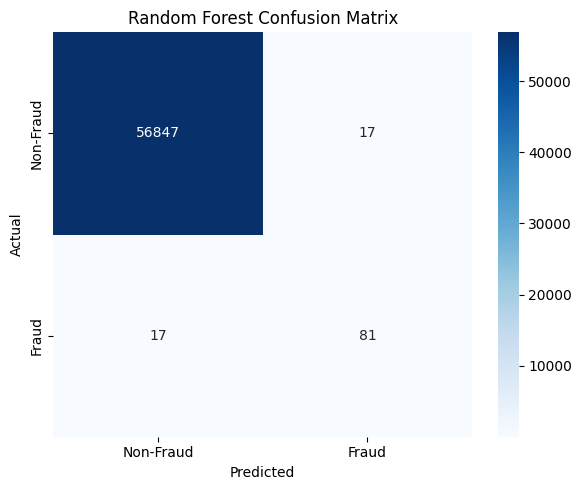

In [40]:
from sklearn.metrics import confusion_matrix

# Logistic Regression confusion matrix
cm_logistic = confusion_matrix(y_test, logistic_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Fraud", "Fraud"],
    yticklabels=["Non-Fraud", "Fraud"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Fraud", "Fraud"],
    yticklabels=["Non-Fraud", "Fraud"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

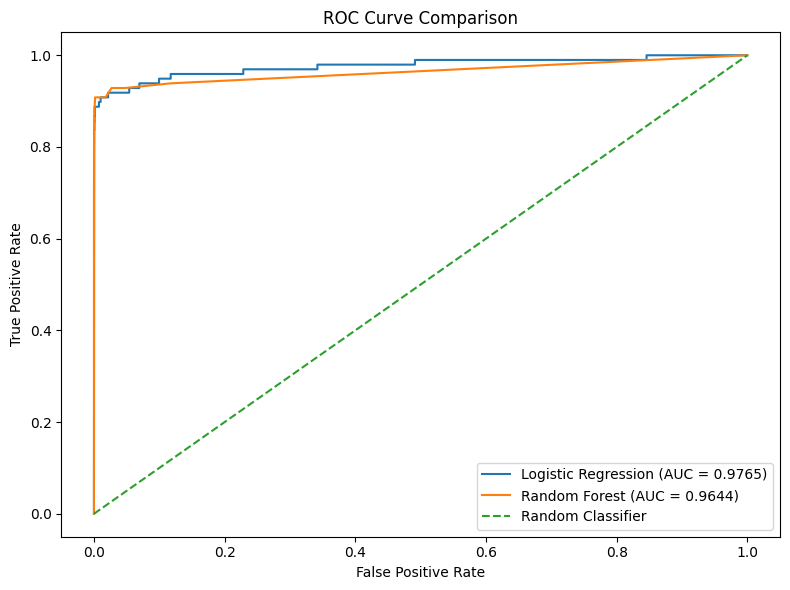

In [41]:
from sklearn.metrics import roc_curve

logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, logistic_prob):.4f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Random Forest Feature Importance

Feature importance shows the relative contribution of each feature to the Random Forest predictions.

This helps identify which transaction characteristics are most useful for distinguishing fraudulent transactions from legitimate transactions.

In [42]:
# Calculate Random Forest feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(10))

,Feature,Importance
14,V14,0.216978
10,V10,0.119804
4,V4,0.116792
12,V12,0.107548
17,V17,0.086269
3,V3,0.070823
11,V11,0.050492
16,V16,0.040146
2,V2,0.038889
9,V9,0.028260


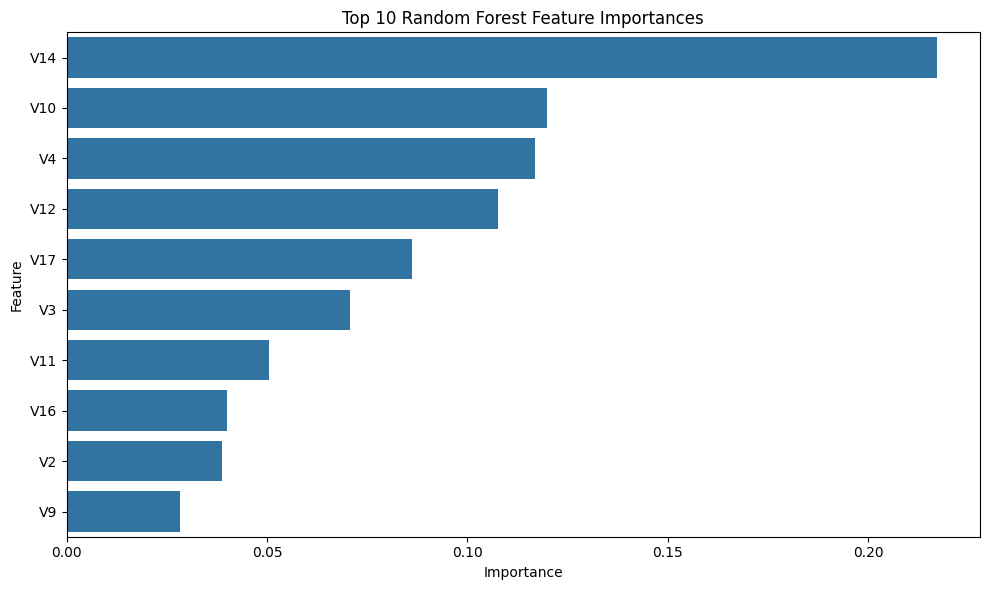

In [43]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 12. Precision vs Recall in Fraud Detection

Precision measures how many transactions predicted as fraudulent are actually fraudulent.

Recall measures how many of the actual fraudulent transactions are successfully detected.

In fraud detection, Recall is often especially important because a false negative means that a fraudulent transaction was missed. However, maximizing Recall can produce more false positives, which may inconvenience legitimate customers.

Therefore, a practical fraud detection system should balance Recall and Precision rather than relying on accuracy alone.

## 13. Scalability

A real-world financial system may need to process millions of transactions per hour.

Logistic Regression is computationally efficient and can be suitable for high-throughput fraud screening, especially when combined with optimized preprocessing and batch or streaming prediction.

Random Forest can provide strong predictive performance but generally requires more computational resources because it uses many decision trees.

For a production system handling approximately one million transactions per hour, the models could be deployed using a scalable cloud or distributed architecture. Predictions could be processed through a streaming system, while the trained model is served through an API or dedicated inference service.

The model should also be monitored regularly because fraud patterns can change over time.

## 14. Conclusion

This project developed a machine learning pipeline for detecting fraudulent credit card transactions in a highly imbalanced dataset.

The dataset contained 284,807 transactions, of which only 492 (0.17%) were fraudulent. Because of this severe class imbalance, accuracy alone was not considered sufficient for evaluating the models. SMOTE was applied only to the training data to balance the minority fraud class while keeping the test data unchanged.

Two classification models were evaluated: Logistic Regression and Random Forest.

Logistic Regression achieved an accuracy of 98.99%, precision of 13.41%, recall of 89.80%, F1-score of 23.34%, and AUC-ROC of 97.65%.

Random Forest achieved an accuracy of 99.94%, precision of 82.65%, recall of 82.65%, F1-score of 82.65%, and AUC-ROC of 96.44%.

Although Logistic Regression achieved higher recall and AUC-ROC, Random Forest provided a much better balance between precision and recall and produced a substantially higher F1-score. Therefore, Random Forest is the preferred model for this analysis when reducing false fraud alerts while still detecting a large proportion of fraudulent transactions is important.

The feature importance analysis showed that V14, V10, V4, V12, and V17 were among the most influential features in the Random Forest model. Since these features are anonymized PCA components, their specific real-world interpretations are not available.

A practical fraud detection system should prioritize appropriate metrics such as Precision, Recall, F1-score, and AUC-ROC rather than relying on accuracy alone. The model should also be monitored and retrained regularly as fraudulent transaction patterns evolve.